# Brain Tumor Detection — Model Evaluation Metrics
Evaluates `classification_v2.keras` (EfficientNetB0) on the held-out test set.

## 1. Config

In [2]:
SCRIPT_DIR   = os.path.abspath(os.path.dirname("."))
REPO_ROOT    = os.path.abspath(os.path.join(SCRIPT_DIR, "..", ".."))
TEST_DIR     = os.path.join(REPO_ROOT, "archive", "Testing")
MODEL_PATH   = os.path.join(REPO_ROOT, "backend", "models", "classification_v2.keras")

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
CLASS_LABELS = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
NUM_CLASSES  = len(CLASS_LABELS)

print("Model :", MODEL_PATH)
print("Test  :", TEST_DIR)
print("Exists:", os.path.exists(MODEL_PATH), os.path.isdir(TEST_DIR))

Model : /Users/rithikmeedinti/MRI-Based-Brain-Tumor-Detection/backend/models/classification_v2.keras
Test  : /Users/rithikmeedinti/MRI-Based-Brain-Tumor-Detection/archive/Testing
Exists: True True


## 2. Load Model

In [3]:
model = tf.keras.models.load_model(MODEL_PATH, compile=False)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "efficientnetb0_tumor_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 3. Load Test Data

In [4]:
test_datagen = ImageDataGenerator()   # no rescale — EfficientNetB0 handles it internally

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    classes=CLASS_LABELS,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

print("Test samples:", test_gen.samples)
print("Class indices:", test_gen.class_indices)

Found 394 images belonging to 4 classes.


Test samples: 394
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


## 4. Run Predictions

In [5]:
y_prob = model.predict(test_gen, verbose=1)          # shape: (N, 4)  — raw softmax probs
y_pred = np.argmax(y_prob, axis=1)                   # predicted class indices
y_true = test_gen.classes                            # ground-truth class indices

print("Predictions shape:", y_prob.shape)
print("Sample probs (first 3):", np.round(y_prob[:3], 3))

/Users/rithikmeedinti/MRI-Based-Brain-Tumor-Detection/backend/models/venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



 1/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step


 2/13 ━━━━━━━━━━━━━━━━━━━━ 4s 384ms/step


 3/13 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step


 4/13 ━━━━━━━━━━━━━━━━━━━━ 2s 333ms/step

...


11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step


12/13 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 437ms/step


Predictions shape: (394, 4)
Sample probs (first 3): [[0.516 0.346 0.023 0.115]
 [0.13  0.473 0.144 0.253]
 [0.166 0.313 0.447 0.073]]


## 5. Overall Accuracy

In [6]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")

Test Loss     : 1.0091
Test Accuracy : 65.74%


## 6. Confusion Matrix

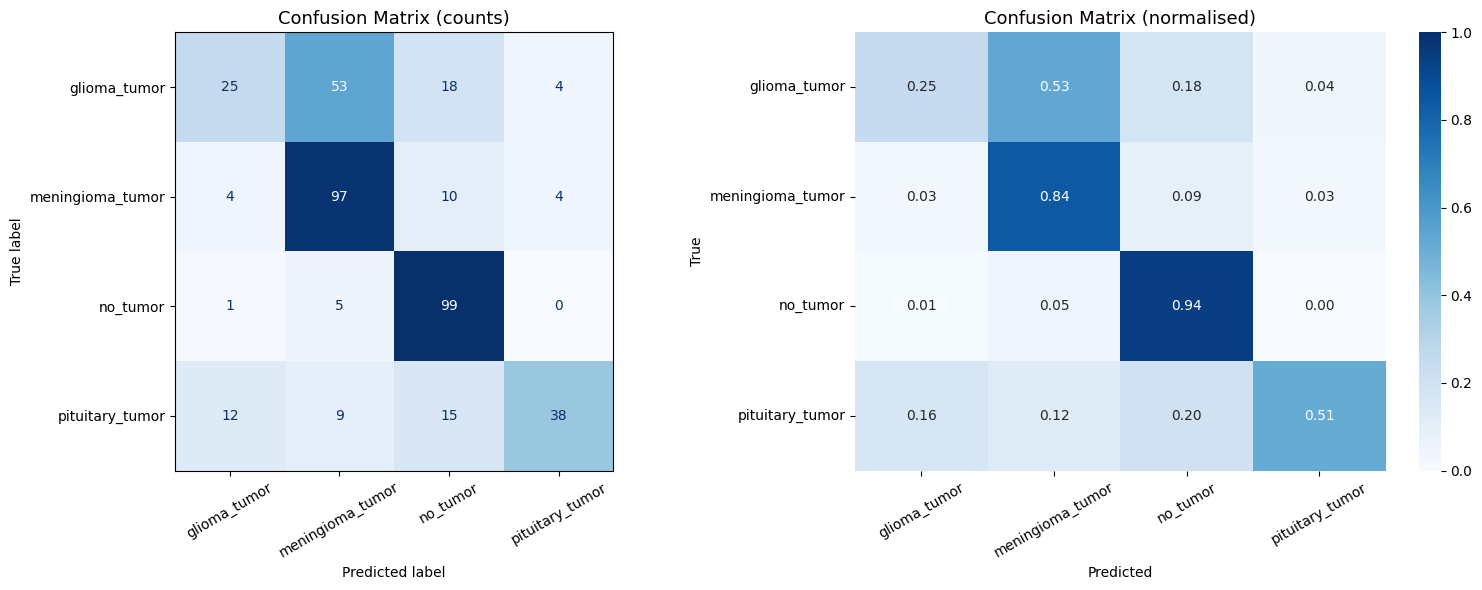


Raw confusion matrix:
[[25 53 18  4]
 [ 4 97 10  4]
 [ 1  5 99  0]
 [12  9 15 38]]


In [7]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (counts)", fontsize=13)
axes[0].tick_params(axis='x', rotation=30)

# Normalised (row = true class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
    ax=axes[1], vmin=0, vmax=1
)
axes[1].set_title("Confusion Matrix (normalised)", fontsize=13)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nRaw confusion matrix:")
print(cm)

## 7. Classification Report (Precision, Recall, F1)

In [8]:
report = classification_report(y_true, y_pred, target_names=CLASS_LABELS, digits=4)
print(report)

                  precision    recall  f1-score   support

    glioma_tumor     0.5952    0.2500    0.3521       100
meningioma_tumor     0.5915    0.8435    0.6953       115
        no_tumor     0.6972    0.9429    0.8016       105
 pituitary_tumor     0.8261    0.5135    0.6333        74

        accuracy                         0.6574       394
       macro avg     0.6775    0.6375    0.6206       394
    weighted avg     0.6647    0.6574    0.6249       394



## 8. Per-Class Accuracy

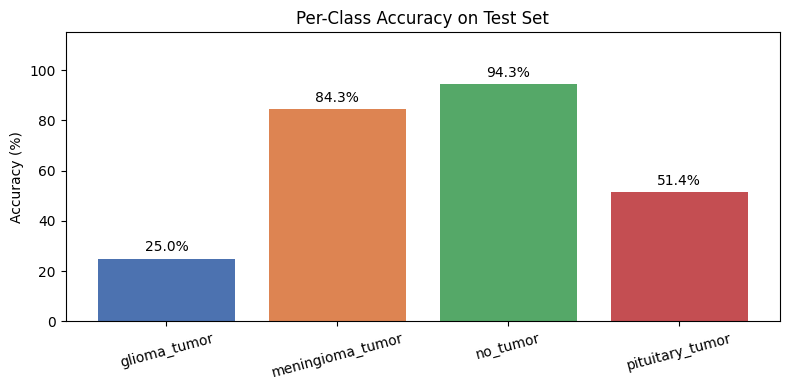

  glioma_tumor              25.00%
  meningioma_tumor          84.35%
  no_tumor                  94.29%
  pituitary_tumor           51.35%


In [9]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASS_LABELS, per_class_acc * 100, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylim(0, 115)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy on Test Set")
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

for label, acc in zip(CLASS_LABELS, per_class_acc):
    print(f"  {label:<25} {acc*100:.2f}%")

## 9. ROC Curves (One-vs-Rest)

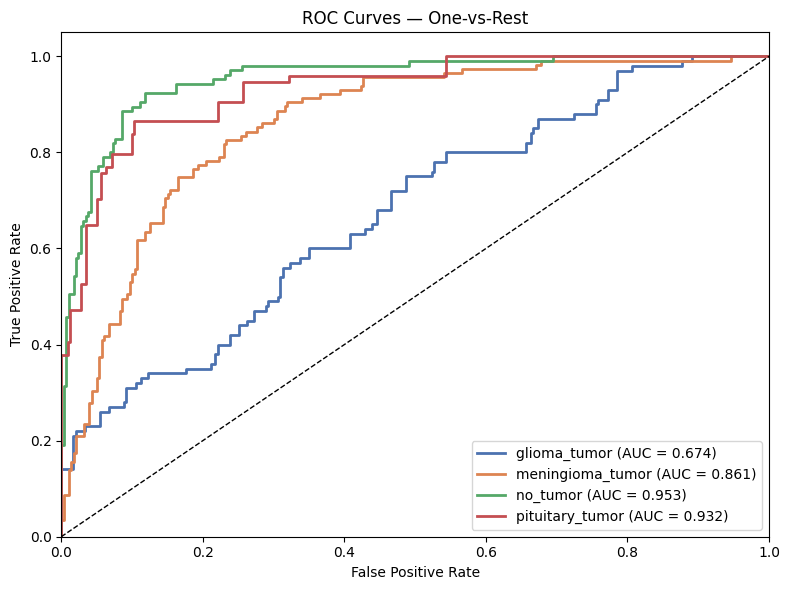

In [10]:
from tensorflow.keras.utils import to_categorical

y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

colors = cycle(["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
fig, ax = plt.subplots(figsize=(8, 6))

for i, (label, color) in enumerate(zip(CLASS_LABELS, colors)):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Confidence Distribution per Class

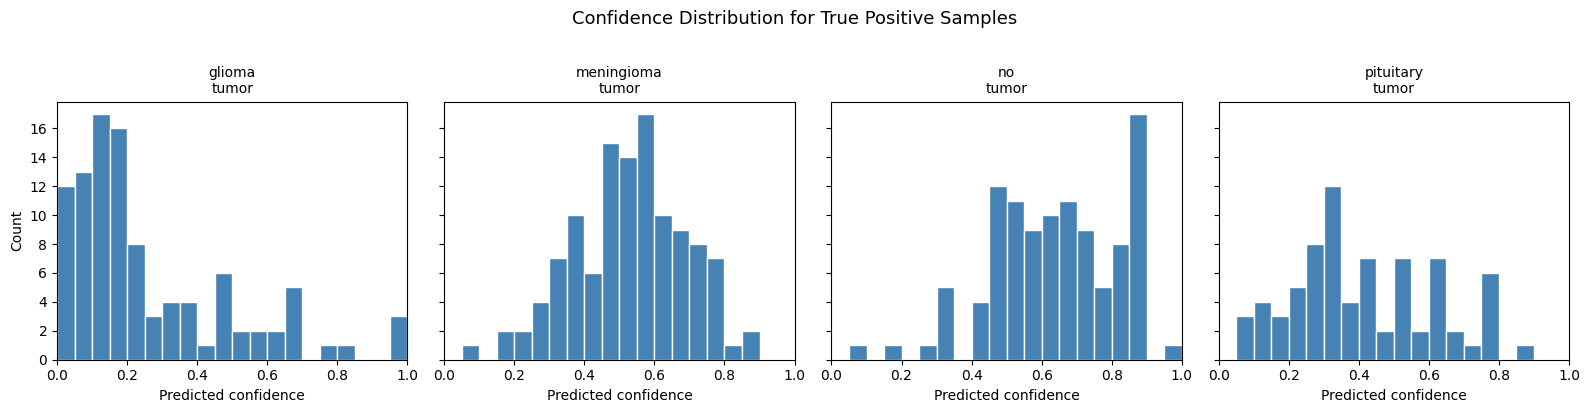

In [11]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4), sharey=True)

for i, (label, ax) in enumerate(zip(CLASS_LABELS, axes)):
    mask = y_true == i
    confs = y_prob[mask, i]
    ax.hist(confs, bins=20, range=(0, 1), color="steelblue", edgecolor="white")
    ax.set_title(label.replace("_", "\n"), fontsize=10)
    ax.set_xlabel("Predicted confidence")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Count")
fig.suptitle("Confidence Distribution for True Positive Samples", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Summary Table

In [12]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)
for i, label in enumerate(CLASS_LABELS):
    fpr_i, tpr_i, _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
    roc_auc_dict[label] = auc(fpr_i, tpr_i)

precision = precision_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)))
recall    = recall_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)))
f1        = f1_score(y_true, y_pred, average=None, labels=list(range(NUM_CLASSES)))

summary = pd.DataFrame({
    "Class"    : CLASS_LABELS,
    "Support"  : cm.sum(axis=1),
    "Accuracy" : np.round(per_class_acc * 100, 2),
    "Precision": np.round(precision * 100, 2),
    "Recall"   : np.round(recall * 100, 2),
    "F1-Score" : np.round(f1 * 100, 2),
    "ROC-AUC"  : [round(roc_auc_dict[l], 4) for l in CLASS_LABELS],
})

print(summary.to_string(index=False))
print(f"\nOverall Test Accuracy: {test_acc*100:.2f}%")
print(f"Macro F1             : {f1.mean()*100:.2f}%")

           Class  Support  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    glioma_tumor      100     25.00      59.52   25.00     35.21   0.6740
meningioma_tumor      115     84.35      59.15   84.35     69.53   0.8610
        no_tumor      105     94.29      69.72   94.29     80.16   0.9533
 pituitary_tumor       74     51.35      82.61   51.35     63.33   0.9321

Overall Test Accuracy: 65.74%
Macro F1             : 62.06%
